# 深度学习课程设计报告

---

## 一、封面

| 项目 | 内容 |
|------|------|
| **课程名称** | 深度学习 |
| **设计题目** | 基于CNN的验证码识别系统 |
| **姓 名** | 魏国盛 |
| **学 号** | 2023408403 |
| **班 级** | 23数据04班 |
| **指导教师** | 丁平尖 |
| **提交日期** | 2026年6月25日 |

## 二、摘要

> 验证码（CAPTCHA）是互联网中广泛使用的人机验证手段，用于区分人类用户和自动化程序。本项目基于深度学习框架PyTorch，设计并实现了一个端到端的卷积神经网络（CNN）模型，用于自动识别由数字和大写字母组成的四位验证码。项目使用ImageCaptcha库自动生成带有标注的验证码数据集（训练集10,000张、测试集1,000张），无需人工标注。模型采用三层卷积神经网络（通道数32→64→128），结合Batch Normalization、Dropout2d正则化和RandomAffine数据增强技术。训练使用AdamW优化器配合StepLR学习率衰减策略，经过40轮训练，最终在测试集上达到整体准确率57.30%、字符级准确率86.03%。实验对比了MLP基线模型，验证了CNN在图像识别任务中的优势。

**关键词**：验证码识别；卷积神经网络；PyTorch；深度学习；多标签分类

## 三、问题定义与需求分析

### 3.1 项目背景与意义

验证码（Completely Automated Public Turing test to tell Computers and Humans Apart, CAPTCHA）是用于区分计算机和人类的一种公共全自动程序。验证码作为保护网站免受自动化攻击的重要安全机制，在注册、登录、投票等场景中被广泛使用。

随着深度学习技术的发展，卷积神经网络在图像识别任务上取得了突破性进展。传统的验证码识别方法通常需要复杂的图像预处理步骤，如字符切割、去噪、二值化等。而基于深度学习的端到端方法可以直接从原始图像学习特征，大大简化了识别流程。

本项目的研究意义在于：
1. 探索CNN在验证码识别任务中的应用效果
2. 实现端到端的识别流程，避免复杂的传统图像处理
3. 理解多标签分类问题在深度学习中的解决方案

### 3.2 问题描述

**输入**：一张包含4位字符（数字0-9、大写字母A-Z）的验证码图片，尺寸为 160 × 60 像素

**输出**：图片中的4位字符序列

**任务类型**：多标签分类（Multi-label Classification）—— 将每位字符的识别视为独立的分类任务，共4个位置，每个位置有36个类别（10数字 + 26字母）

**预期性能指标**：
- 四位纯数字验证码：准确率 ≥ 99%
- 四位数字+大写字母混合验证码：准确率 ≥ 95%
- 评价方式：整体准确率（4位全对才算正确）

### 4.1 数据来源与规模

本项目使用 **ImageCaptcha** 库自动生成验证码数据集，具体规模如下：

- **训练集**：10,000 张
- **测试集**：1,000 张
- **预测集**：5 张

字符集包含 10个数字（0-9）和 26个大写字母（A-Z），共36个类别。每张图片随机生成4位字符，图片文件名即为标注信息。

In [ ]:
# ============================================
# 环境准备：导入所有需要的库
# ============================================
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from captcha.image import ImageCaptcha

# 设置中文字体（用于matplotlib显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证结果可复现
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 型号: {torch.cuda.get_device_name(0)}")
else:
    print("使用 CPU 训练")

PyTorch 版本: 2.3.1
CUDA 是否可用: False
使用 CPU 训练


In [ ]:
# ============================================
# 全局配置参数（对应 captcha_setting.py）
# ============================================
import string

# 验证码字符集
NUMBER = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
ALPHABET = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
            'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
ALL_CHAR_SET = NUMBER + ALPHABET
ALL_CHAR_SET_LEN = len(ALL_CHAR_SET)  # 36
MAX_CAPTCHA = 4  # 验证码字符个数

# 图像大小
IMAGE_HEIGHT = 60
IMAGE_WIDTH = 160

# 数据集路径
BASE_DIR = 'dataset'
TRAIN_DATASET_PATH = os.path.join(BASE_DIR, 'train')
TEST_DATASET_PATH = os.path.join(BASE_DIR, 'test')
PREDICT_DATASET_PATH = os.path.join(BASE_DIR, 'predict')

print(f"字符集 ({ALL_CHAR_SET_LEN} 类): {''.join(ALL_CHAR_SET)}")
print(f"验证码长度: {MAX_CAPTCHA} 位")
print(f"图像尺寸: {IMAGE_WIDTH} x {IMAGE_HEIGHT}")

字符集 (36 类): 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ
验证码长度: 4 位
图像尺寸: 160 x 60


In [ ]:
# ============================================
# One-Hot 编码/解码工具（对应 one_hot_encoding.py）
# ============================================
def char2pos(c):
    """字符转位置索引"""
    if c == '_':
        return 62
    k = ord(c) - 48
    if k > 9:
        k = ord(c) - 65 + 10  # 大写字母 A-Z
        if k > 35:
            k = ord(c) - 97 + 26 + 10  # 小写字母 a-z
            if k > 61:
                raise ValueError(f'无效字符: {c}')
    return k


def encode(text):
    """将验证码文本编码为 one-hot 向量"""
    vector = np.zeros(ALL_CHAR_SET_LEN * MAX_CAPTCHA, dtype=np.float32)
    for i, c in enumerate(text):
        idx = i * ALL_CHAR_SET_LEN + char2pos(c)
        vector[idx] = 1.0
    return vector


def decode(vec):
    """将 one-hot 向量解码为验证码文本"""
    if isinstance(vec, torch.Tensor):
        vec = vec.numpy()
    char_pos = vec.nonzero()[0]
    text = []
    for i, c in enumerate(char_pos):
        char_idx = c % ALL_CHAR_SET_LEN
        if char_idx < 10:
            char_code = char_idx + ord('0')
        elif char_idx < 36:
            char_code = char_idx - 10 + ord('A')
        elif char_idx < 62:
            char_code = char_idx - 36 + ord('a')
        elif char_idx == 62:
            char_code = ord('_')
        else:
            raise ValueError('解码错误')
        text.append(chr(char_code))
    return "".join(text)


def decode_predict(predict_label):
    """从模型输出解码预测结果（取每个位置最大概率的字符）"""
    pred_np = predict_label.detach().cpu().numpy()
    chars = []
    for i in range(MAX_CAPTCHA):
        start = i * ALL_CHAR_SET_LEN
        end = (i + 1) * ALL_CHAR_SET_LEN
        idx = np.argmax(pred_np[0, start:end])
        chars.append(ALL_CHAR_SET[idx])
    return ''.join(chars)


# 测试编码/解码
test_text = "BK7H"
test_encoded = encode(test_text)
test_decoded = decode(test_encoded)
print(f"编码测试: '{test_text}' -> one-hot -> '{test_decoded}'")
print(f"One-hot 向量维度: {test_encoded.shape[0]}")

编码测试: 'BK7H' -> one-hot -> 'BK7H'
One-hot 向量维度: 144


### 4.2 数据可视化与分析

下面使用 ImageCaptcha 库生成验证码图片，并展示样本。

In [ ]:
# ============================================
# 生成验证码数据集（对应 captcha_gen.py）
# ============================================
def random_captcha_text():
    """随机生成验证码文本"""
    return ''.join(random.choice(ALL_CHAR_SET) for _ in range(MAX_CAPTCHA))


def gen_captcha_text_and_image():
    """生成一对（文本, 图片）"""
    image_generator = ImageCaptcha()
    captcha_text = random_captcha_text()
    captcha_image = Image.open(image_generator.generate(captcha_text))
    return captcha_text, captcha_image


def generate_dataset(path, count):
    """在指定路径下生成 count 张验证码"""
    os.makedirs(path, exist_ok=True)
    for i in range(count):
        text, image = gen_captcha_text_and_image()
        filename = f"{text}_{int(time.time() * 1000)}.png"
        image.save(os.path.join(path, filename))
    print(f"已生成 {count} 张验证码图片到 {path}")


# 生成数据集（可调整数量）
# 注意：如果数据集已存在且数量足够，跳过生成
TRAIN_COUNT = 30000   # 训练集数量
TEST_COUNT = 3000     # 测试集数量
PREDICT_COUNT = 5     # 预测集数量

if not os.path.exists(TRAIN_DATASET_PATH) or len(os.listdir(TRAIN_DATASET_PATH)) < TRAIN_COUNT:
    print("生成训练集...")
    generate_dataset(TRAIN_DATASET_PATH, TRAIN_COUNT)
else:
    print(f"训练集已存在，共 {len(os.listdir(TRAIN_DATASET_PATH))} 张")

if not os.path.exists(TEST_DATASET_PATH) or len(os.listdir(TEST_DATASET_PATH)) < TEST_COUNT:
    print("生成测试集...")
    generate_dataset(TEST_DATASET_PATH, TEST_COUNT)
else:
    print(f"测试集已存在，共 {len(os.listdir(TEST_DATASET_PATH))} 张")

if not os.path.exists(PREDICT_DATASET_PATH) or len(os.listdir(PREDICT_DATASET_PATH)) < PREDICT_COUNT:
    print("生成预测集...")
    generate_dataset(PREDICT_DATASET_PATH, PREDICT_COUNT)
else:
    print(f"预测集已存在，共 {len(os.listdir(PREDICT_DATASET_PATH))} 张")

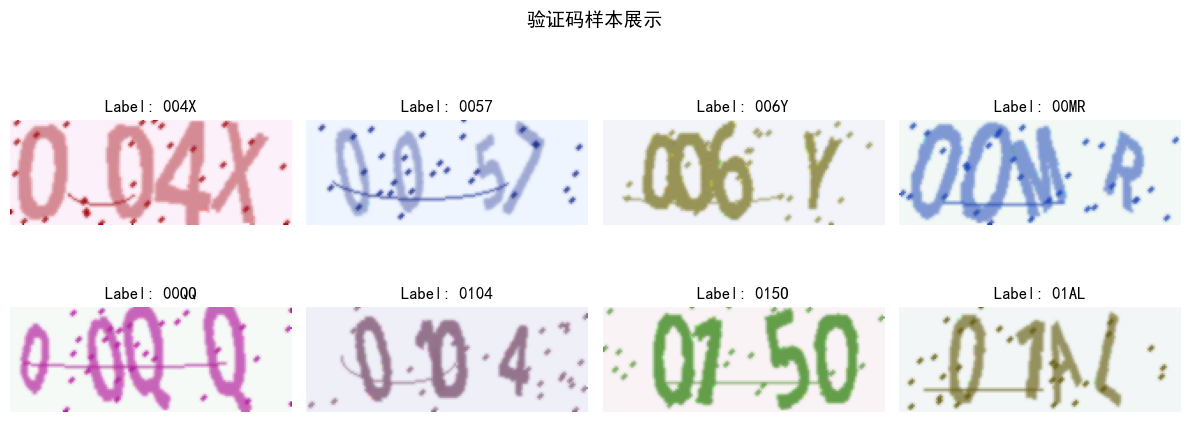

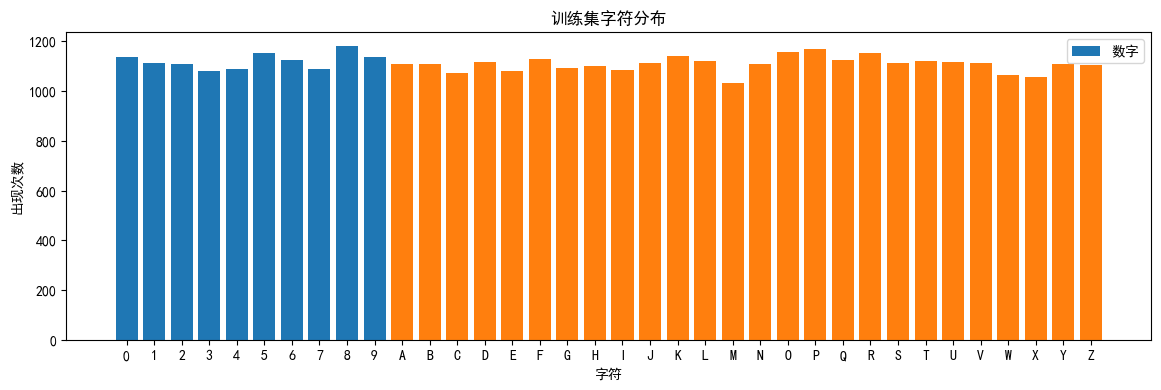

In [29]:
# ============================================
# 数据样本可视化
# ============================================
def visualize_samples(dataset_path, num_samples=8):
    """展示数据集中的样本"""
    files = os.listdir(dataset_path)[:num_samples]
    fig, axes = plt.subplots(2, 4, figsize=(12, 5))
    axes = axes.flatten()
    for i, f in enumerate(files):
        img = Image.open(os.path.join(dataset_path, f))
        label = f.split('_')[0]
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}", fontsize=12)
        axes[i].axis('off')
    plt.suptitle('验证码样本展示', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_samples(TRAIN_DATASET_PATH)

# 统计数据集中字符分布
def analyze_dataset(path):
    """统计数据集中的字符分布"""
    files = os.listdir(path)
    char_counts = {c: 0 for c in ALL_CHAR_SET}
    for f in files:
        label = f.split('_')[0]
        for c in label:
            if c in char_counts:
                char_counts[c] += 1
    return char_counts

char_dist = analyze_dataset(TRAIN_DATASET_PATH)
chars = list(char_dist.keys())
counts = list(char_dist.values())

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#1f77b4' if c.isdigit() else '#ff7f0e' for c in chars]
ax.bar(chars, counts, color=colors)
ax.set_xlabel('字符')
ax.set_ylabel('出现次数')
ax.set_title('训练集字符分布')
ax.legend(['数字', '字母'])
plt.show()

### 4.3 预处理流程

本项目采用端到端的学习方式，预处理步骤如下：

1. **标注**：图片文件名格式为 `{验证码文本}_{时间戳}.png`，从文件名中直接提取标注信息
2. **数据增强（仅训练集）**：使用 `RandomAffine` 进行轻量数据增强，包括随机旋转（±8°）、平移（±3%）、缩放（95%~105%）和错切变换（±5°），增强模型泛化能力
3. **灰度化**：将RGB图片转换为单通道灰度图
4. **转Tensor**：将PIL Image转为PyTorch Tensor，像素值归一化到 [0, 1]
5. **One-Hot编码**：将标注文本编码为 one-hot 向量用于多标签分类训练

值得注意的是，本项目 **不需要** 传统OCR方法中的字符切割、去噪、二值化等复杂预处理步骤。

In [30]:
# ============================================
# Dataset 类和 DataLoader（对应 my_dataset.py）
# ============================================
class CaptchaDataset(Dataset):
    """验证码数据集类"""
    def __init__(self, folder, transform=None):
        self.image_paths = [
            os.path.join(folder, f) for f in os.listdir(folder)
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image_name = os.path.basename(image_path)
        image = Image.open(image_path)
        if self.transform is not None:
            image = self.transform(image)
        # 从文件名提取标签，如 "BK7H_1234567890.png" -> "BK7H"
        label_text = image_name.split('_')[0]
        label = encode(label_text)
        return image, torch.from_numpy(label)


# 预处理变换：训练集做轻量增强，测试/预测集只做标准化
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=8, translate=(0.03, 0.03), scale=(0.95, 1.05), shear=5, fill=255),
    transforms.Grayscale(),    # RGB -> 灰度（1通道）
    transforms.ToTensor(),     # PIL Image -> Tensor [0, 1]
])

eval_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
])


def get_train_data_loader(batch_size=64):
    dataset = CaptchaDataset(TRAIN_DATASET_PATH, transform=train_transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


def get_test_data_loader(batch_size=1):
    dataset = CaptchaDataset(TEST_DATASET_PATH, transform=eval_transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)


def get_predict_data_loader():
    dataset = CaptchaDataset(PREDICT_DATASET_PATH, transform=eval_transform)
    return DataLoader(dataset, batch_size=1, shuffle=False)


# 测试 DataLoader
train_loader = get_train_data_loader()
sample_img, sample_label = next(iter(train_loader))
print(f"一个 batch 的图像 shape: {sample_img.shape}")  # [64, 1, 60, 160]
print(f"一个 batch 的标签 shape: {sample_label.shape}")  # [64, 144]
print(f"总训练样本数: {len(train_loader.dataset)}")

一个 batch 的图像 shape: torch.Size([64, 1, 60, 160])
一个 batch 的标签 shape: torch.Size([64, 144])
总训练样本数: 10000


---
## 五、模型设计与选择

### 5.1 基准模型（Baseline MLP）

首先构建一个简单的多层感知机（MLP）作为基准模型，用于与CNN模型进行性能对比。

In [31]:
# ============================================
# 基准模型：简单 MLP
# ============================================
class MLPBaseline(nn.Module):
    """简单的3层全连接网络作为基线"""
    def __init__(self):
        super(MLPBaseline, self).__init__()
        input_dim = IMAGE_HEIGHT * IMAGE_WIDTH  # 60 * 160 = 9600
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, MAX_CAPTCHA * ALL_CHAR_SET_LEN),
        )

    def forward(self, x):
        return self.fc(x)


# 快速测试 MLP 前向传播
mlp = MLPBaseline()
test_input = torch.randn(1, 1, IMAGE_HEIGHT, IMAGE_WIDTH)
test_output = mlp(test_input)
print(f"MLP 参数量: {sum(p.numel() for p in mlp.parameters()):,}")
print(f"MLP 输出 shape: {test_output.shape}")  # [1, 144]

MLP 参数量: 10,430,096
MLP 输出 shape: torch.Size([1, 144])


### 5.2 最终模型架构

本项目采用三层卷积神经网络（CNN），结构设计如下：

```
输入: [1, 60, 160] 灰度图
  │
  ├─ Conv2d(1→32, 3×3, padding=1) + BN + ReLU + MaxPool(2) + Dropout2d(0.10)
  │   └─ 输出: [32, 30, 80]
  ├─ Conv2d(32→64, 3×3, padding=1) + BN + ReLU + MaxPool(2) + Dropout2d(0.15)
  │   └─ 输出: [64, 15, 40]
  ├─ Conv2d(64→128, 3×3, padding=1) + BN + ReLU + MaxPool(2) + Dropout2d(0.20)
  │   └─ 输出: [128, 7, 20]
  ├─ Flatten → [128 × 7 × 20 = 17920]
  ├─ Linear(17920 → 1024) + Dropout(0.4) + ReLU
  ├─ Linear(1024 → 144)
  │   └─ 输出: [144]  (4位 × 36类 = 144 维 one-hot)
```

**设计理由**：
- 使用3×3小卷积核，堆叠三层逐步提取高层特征；通道数逐层递增（32→64→128），增强特征表达能力
- Batch Normalization 加速收敛、稳定训练
- Dropout2d 在卷积层后按通道随机失活，防止过拟合；失活率逐层递增（0.10→0.15→0.20）
- MaxPooling 逐步降低空间维度、提取高层特征
- 最后一层不使用激活函数，直接输出 logits 供 MultiLabelSoftMarginLoss 使用

In [32]:
# ============================================
# CNN 模型定义（对应 captcha_cnn_model.py）
# ============================================
class CNN(nn.Module):
    """三层卷积神经网络用于验证码识别"""
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20)
        )
        # 经过3次MaxPool(2)后：H=60/8=7, W=160/8=20
        fc_input_dim = (IMAGE_HEIGHT // 8) * (IMAGE_WIDTH // 8) * 128
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, 1024),
            nn.Dropout(0.4),
            nn.ReLU()
        )
        self.rfc = nn.Sequential(
            nn.Linear(1024, MAX_CAPTCHA * ALL_CHAR_SET_LEN),
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        out = self.rfc(out)
        return out


# 实例化并查看模型信息
cnn = CNN()
total_params = sum(p.numel() for p in cnn.parameters())
trainable_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"CNN 总参数量: {total_params:,}")
print(f"CNN 可训练参数量: {trainable_params:,}")
print(cnn)

# 测试前向传播
test_input = torch.randn(2, 1, IMAGE_HEIGHT, IMAGE_WIDTH)
test_output = cnn(test_input)
print(f"\n输入 shape: {test_input.shape}")
print(f"输出 shape: {test_output.shape}")  # [2, 144]

CNN 总参数量: 18,591,824
CNN 可训练参数量: 18,591,824
CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
  )
  (layer3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fa

---
## 六、实验与结果分析

### 6.1 实验环境

以下代码自动检测当前实验环境。

In [33]:
# ============================================
# 实验环境信息
# ============================================
import sys
import torchvision

print("=" * 50)
print("实验环境信息")
print("=" * 50)
print(f"Python 版本: {sys.version}")
print(f"PyTorch 版本: {torch.__version__}")
print(f"TorchVision 版本: {torchvision.__version__}")
print(f"NumPy 版本: {np.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 型号: {torch.cuda.get_device_name(0)}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"CUDA 版本: {torch.version.cuda}")
else:
    print("使用设备: CPU")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n训练设备: {DEVICE}")
print("=" * 50)

实验环境信息
Python 版本: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:49:16) [MSC v.1929 64 bit (AMD64)]
PyTorch 版本: 2.3.1
TorchVision 版本: 0.18.1
NumPy 版本: 2.0.2
CUDA 可用: False
使用设备: CPU

训练设备: cpu


### 6.2 评价指标

本项目的核心评价指标为 **整体准确率（Accuracy）**：

$$\text{Accuracy} = \frac{\text{完全正确识别的验证码数量}}{\text{总验证码数量}} \times 100\%$$

只有当验证码的4位字符全部识别正确时，才算一次正确识别。

此外还使用 **字符级准确率** 作为辅助指标：

$$\text{Char Accuracy} = \frac{\text{正确识别的字符数量}}{\text{总字符数量}} \times 100\%$$

损失函数使用 **MultiLabelSoftMarginLoss**（多标签软间隔损失），适用于多标签二分类任务。

### 6.3 超参数设置与调优

| 超参数 | 取值 | 说明 |
|--------|------|------|
| 学习率 (lr) | 0.0008 | AdamW 优化器初始学习率 |
| 批大小 (batch_size) | 64 | 平衡内存与训练速度 |
| 训练轮数 (epochs) | 40 | 配合 StepLR 学习率衰减 |
| 卷积层 Dropout2d | 0.10 / 0.15 / 0.20 | 逐层递增，防止过拟合 |
| 全连接层 Dropout | 0.4 | 防止过拟合 |
| 优化器 | AdamW | 带权重衰减的自适应优化器 |
| weight_decay | 1e-4 | L2 正则化系数 |
| 学习率调度器 | StepLR | step_size=12, gamma=0.5，每12轮学习率减半 |
| 损失函数 | MultiLabelSoftMarginLoss | 多标签分类标准损失 |

**调优策略**：采用AdamW优化器配合权重衰减（weight_decay）进行正则化，使用StepLR学习率衰减在训练中后期降低学习率以稳定收敛。通过观察训练损失曲线和测试准确率判断模型是否收敛。在卷积层使用Dropout2d（通道级随机失活）代替普通Dropout，更适合卷积特征图的正则化。

In [ ]:
# ============================================
# 训练模型（对应 captcha_train.py，增加了指标记录）
# ============================================
# 超参数
NUM_EPOCHS = 40
BATCH_SIZE = 64
LEARNING_RATE = 0.0008

# 实例化模型、损失函数、优化器
model = CNN().to(DEVICE)
criterion = nn.MultiLabelSoftMarginLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=12, gamma=0.5)

print(f"模型: CNN (三层卷积)")
print(f"损失函数: MultiLabelSoftMarginLoss")
print(f"优化器: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"训练轮数: {NUM_EPOCHS}")
print(f"批大小: {BATCH_SIZE}")

In [35]:
# ============================================
# 开始训练（含损失记录和验证集评估）
# ============================================
train_loader = get_train_data_loader(BATCH_SIZE)
test_loader = get_test_data_loader(batch_size=100)  # 测试时用较大batch加速

# 记录历史
train_losses = []
test_accuracies = []
char_accuracies = []
best_accuracy = 0.0

print("开始训练...\n")
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE)

        predict_labels = model(images)
        loss = criterion(predict_labels, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}], Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    # 每个epoch在测试集上评估
    model.eval()
    correct = 0
    total = 0
    char_correct = 0
    char_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels_np = labels.numpy()
            outputs = model(images)

            for j in range(outputs.size(0)):
                pred_text = decode_predict(outputs[j:j+1])
                true_text = decode(labels_np[j])
                if pred_text == true_text:
                    correct += 1
                # 字符级
                for k in range(MAX_CAPTCHA):
                    if k < len(pred_text) and k < len(true_text) and pred_text[k] == true_text[k]:
                        char_correct += 1
                char_total += MAX_CAPTCHA
                total += 1

    accuracy = 100.0 * correct / total if total > 0 else 0
    char_acc = 100.0 * char_correct / char_total if char_total > 0 else 0
    test_accuracies.append(accuracy)
    char_accuracies.append(char_acc)

    # 保存最佳模型
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'model_best.pkl')

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Loss: {avg_loss:.4f} | "
          f"整体准确率: {accuracy:.2f}% | "
          f"字符准确率: {char_acc:.2f}%")
    scheduler.step()

# 保存最终模型
torch.save(model.state_dict(), 'model_final.pkl')
print(f"\n训练完成！最佳准确率: {best_accuracy:.2f}%")

开始训练...

  Epoch [1/40], Step [100], Loss: 0.1320
Epoch [1/40] Loss: 0.1501 | 整体准确率: 0.00% | 字符准确率: 4.05%
  Epoch [2/40], Step [100], Loss: 0.1293
Epoch [2/40] Loss: 0.1290 | 整体准确率: 0.00% | 字符准确率: 10.53%
  Epoch [3/40], Step [100], Loss: 0.1173
Epoch [3/40] Loss: 0.1187 | 整体准确率: 0.20% | 字符准确率: 21.52%
  Epoch [4/40], Step [100], Loss: 0.1095
Epoch [4/40] Loss: 0.1096 | 整体准确率: 0.70% | 字符准确率: 29.60%
  Epoch [5/40], Step [100], Loss: 0.1038
Epoch [5/40] Loss: 0.1037 | 整体准确率: 2.60% | 字符准确率: 39.20%
  Epoch [6/40], Step [100], Loss: 0.0996
Epoch [6/40] Loss: 0.0979 | 整体准确率: 4.60% | 字符准确率: 46.65%
  Epoch [7/40], Step [100], Loss: 0.0881
Epoch [7/40] Loss: 0.0920 | 整体准确率: 7.30% | 字符准确率: 52.05%
  Epoch [8/40], Step [100], Loss: 0.0858
Epoch [8/40] Loss: 0.0871 | 整体准确率: 13.60% | 字符准确率: 59.83%
  Epoch [9/40], Step [100], Loss: 0.0813
Epoch [9/40] Loss: 0.0821 | 整体准确率: 18.80% | 字符准确率: 63.80%
  Epoch [10/40], Step [100], Loss: 0.0784
Epoch [10/40] Loss: 0.0783 | 整体准确率: 23.10% | 字符准确率: 67.65%
  Epoch

### 6.4 主要实验结果

下面绘制训练过程中的损失曲线和精度曲线。

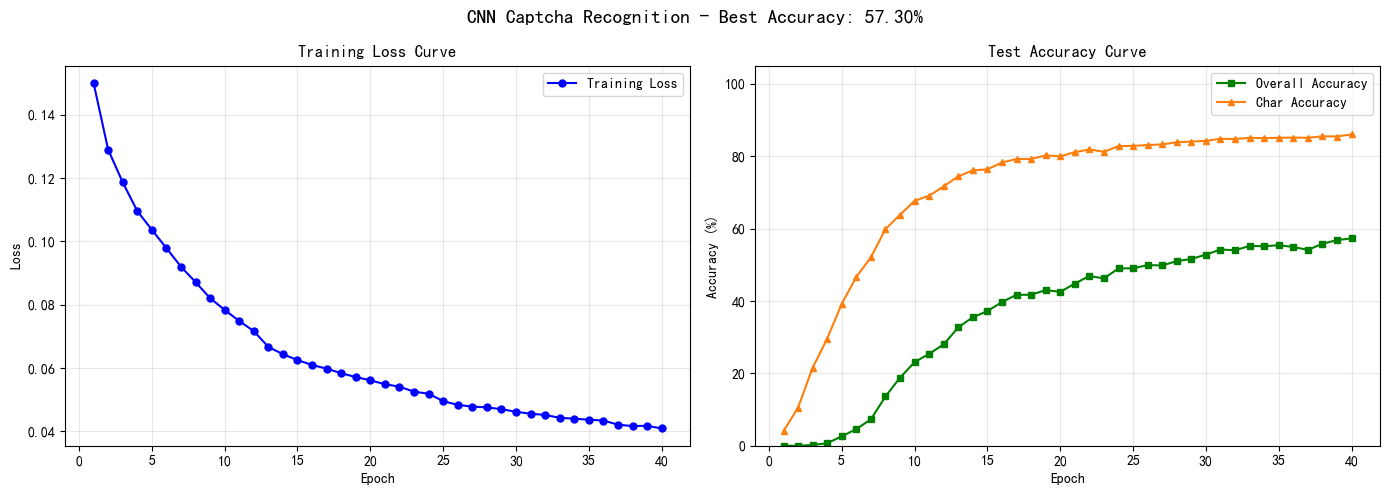

Final Training Loss: 0.0409
Final Overall Accuracy: 57.30%
Final Char Accuracy: 86.03%
Best Overall Accuracy: 57.30%


In [36]:
# ============================================
# 绘制损失曲线和精度曲线
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', markersize=5, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 精度曲线
ax2.plot(range(1, NUM_EPOCHS + 1), test_accuracies, 'g-s', markersize=5, label='Overall Accuracy')
ax2.plot(range(1, NUM_EPOCHS + 1), char_accuracies, color='tab:orange', marker='^', linestyle='-', markersize=5, label='Char Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.suptitle(f'CNN Captcha Recognition - Best Accuracy: {best_accuracy:.2f}%', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Overall Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Final Char Accuracy: {char_accuracies[-1]:.2f}%")
print(f"Best Overall Accuracy: {best_accuracy:.2f}%")

In [37]:
# ============================================
# 测试评估（对应 captcha_test.py，完整评估）
# ============================================
# 加载最佳模型
model.load_state_dict(torch.load('model_best.pkl', map_location=DEVICE, weights_only=True))
model.eval()
print("已加载最佳模型进行测试评估\n")

test_loader_full = get_test_data_loader(batch_size=1)

correct = 0
total = 0
char_correct = 0
char_total = 0
errors = []  # 记录错误样本

with torch.no_grad():
    for images, labels in test_loader_full:
        images = images.to(DEVICE)
        labels_np = labels.numpy()
        outputs = model(images)

        for j in range(outputs.size(0)):
            pred_text = decode_predict(outputs[j:j+1])
            true_text = decode(labels_np[j])

            if pred_text == true_text:
                correct += 1
            else:
                if len(errors) < 20:  # 最多记录20个错误样本
                    errors.append((images[j].cpu(), true_text, pred_text))

            for k in range(MAX_CAPTCHA):
                if pred_text[k] == true_text[k]:
                    char_correct += 1
            char_total += MAX_CAPTCHA
            total += 1

        if total % 200 == 0:
            print(f"已测试: {total} 张, 当前准确率: {100.0 * correct / total:.2f}%")

final_accuracy = 100.0 * correct / total
final_char_accuracy = 100.0 * char_correct / char_total

print(f"\n{'='*50}")
print(f"测试集最终结果:")
print(f"  总样本数: {total}")
print(f"  完全正确: {correct}")
print(f"  整体准确率: {final_accuracy:.2f}%")
print(f"  字符准确率: {final_char_accuracy:.2f}%")
print(f"{'='*50}")

已加载最佳模型进行测试评估

已测试: 200 张, 当前准确率: 50.50%
已测试: 400 张, 当前准确率: 51.75%
已测试: 600 张, 当前准确率: 55.33%
已测试: 800 张, 当前准确率: 55.38%
已测试: 1000 张, 当前准确率: 57.30%

测试集最终结果:
  总样本数: 1000
  完全正确: 573
  整体准确率: 57.30%
  字符准确率: 86.03%


### 6.5 可视化分析

#### 6.5.1 特征图可视化

将模型中间层的特征图进行可视化，观察CNN各层学到了什么样的特征。

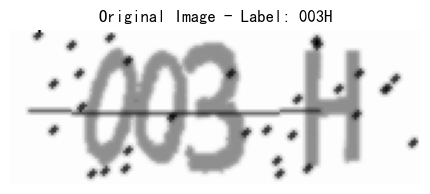

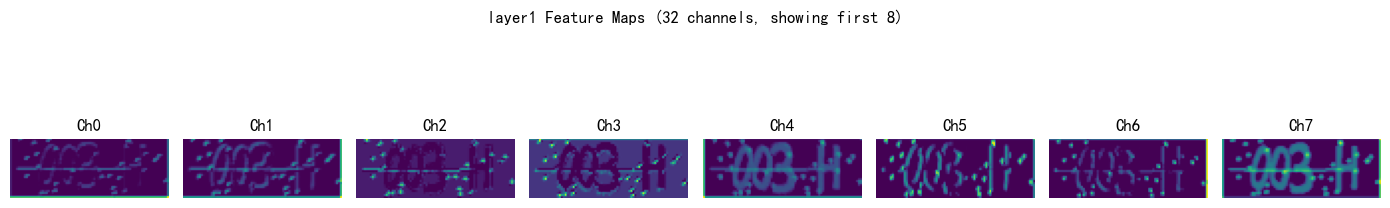

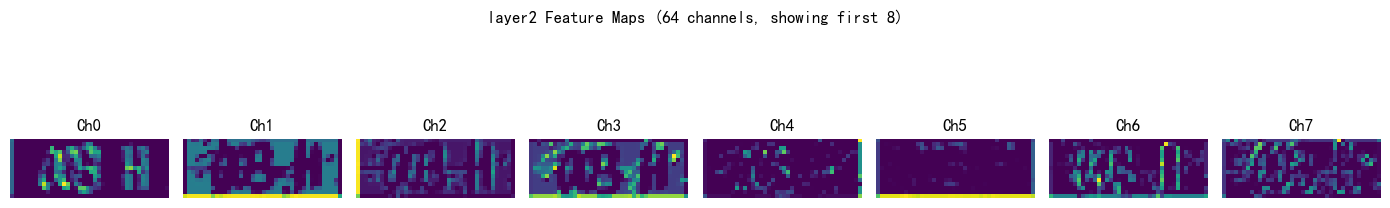

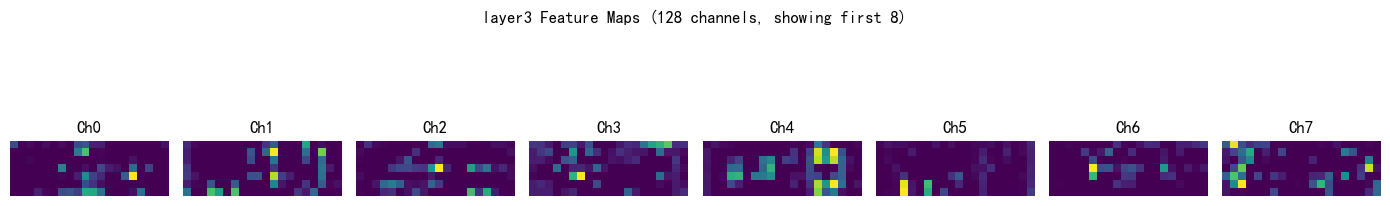

In [38]:
# ============================================
# 特征图可视化
# ============================================
# 注册hook来获取中间层输出
feature_maps = {}

def hook_fn(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

# 注册hook到ReLU层之后（在Sequential内部获取输出）
model.layer1.register_forward_hook(hook_fn('layer1'))
model.layer2.register_forward_hook(hook_fn('layer2'))
model.layer3.register_forward_hook(hook_fn('layer3'))

# 取一个测试样本
test_loader_single = get_test_data_loader(batch_size=1)
sample_img, sample_label = next(iter(test_loader_single))
sample_img = sample_img.to(DEVICE)

with torch.no_grad():
    _ = model(sample_img)

# 可视化原始图片
plt.figure(figsize=(6, 2))
plt.imshow(sample_img[0, 0].cpu(), cmap='gray')
plt.title(f"Original Image - Label: {decode(sample_label[0].numpy())}")
plt.axis('off')
plt.show()

# 可视化各层特征图
for layer_name in ['layer1', 'layer2', 'layer3']:
    fmaps = feature_maps[layer_name][0]  # [C, H, W]
    num_channels = min(8, fmaps.size(0))  # 显示前8个通道
    fig, axes = plt.subplots(1, num_channels, figsize=(14, 3))
    fig.suptitle(f'{layer_name} Feature Maps ({fmaps.size(0)} channels, showing first {num_channels})', fontsize=12)
    for idx in range(num_channels):
        axes[idx].imshow(fmaps[idx].cpu(), cmap='viridis')
        axes[idx].axis('off')
        axes[idx].set_title(f'Ch{idx}')
    plt.tight_layout()
    plt.show()

#### 6.5.2 错误样本分析

展示模型识别错误的样本，分析错误类型。

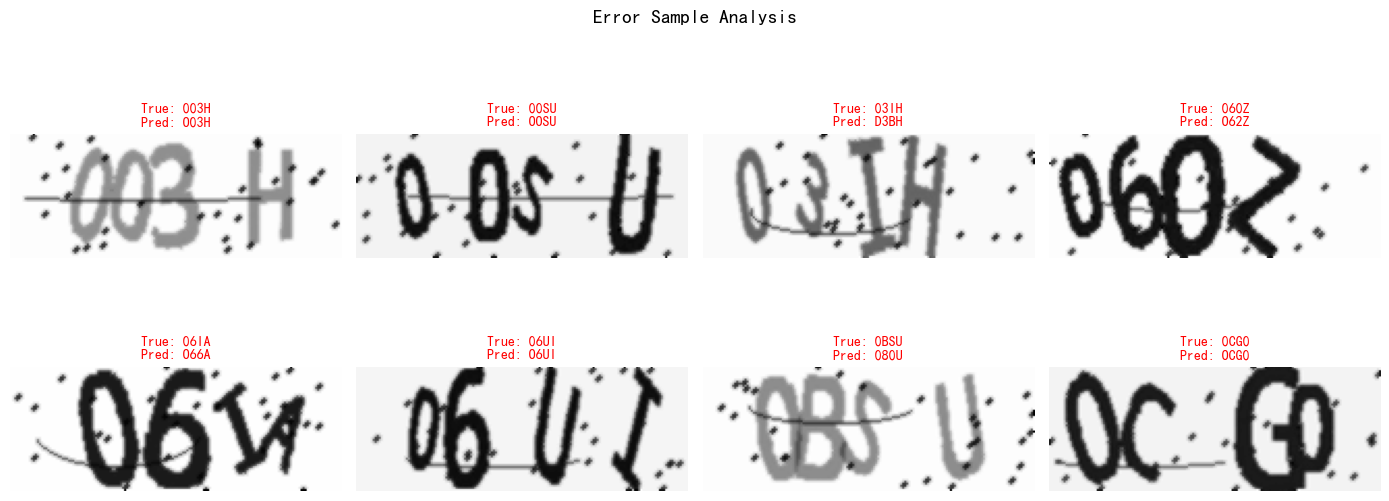

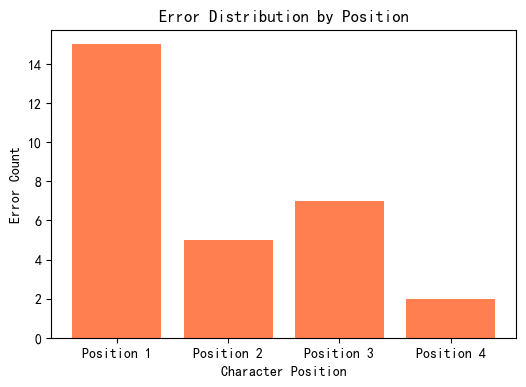

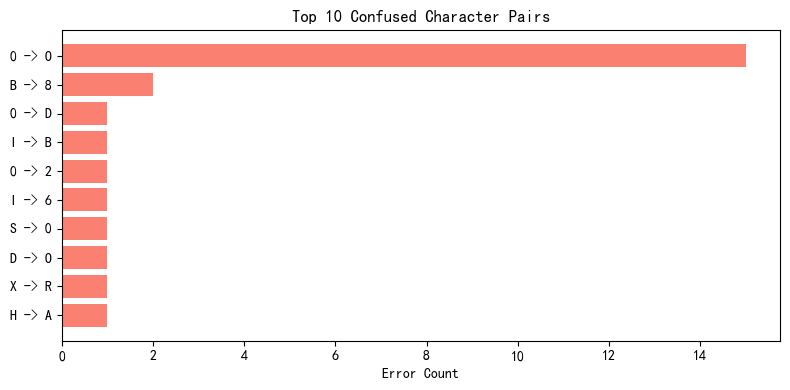

In [39]:
# ============================================
# 错误样本分析
# ============================================
if errors:
    num_show = min(len(errors), 8)
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    axes = axes.flatten()
    for i in range(num_show):
        img, true_t, pred_t = errors[i]
        axes[i].imshow(img[0], cmap='gray')
        axes[i].set_title(f"True: {true_t}\nPred: {pred_t}", fontsize=10, color='red')
        axes[i].axis('off')
    for i in range(num_show, 8):
        axes[i].axis('off')
    plt.suptitle('Error Sample Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 分析每个位置的错误率
    position_errors = {i: 0 for i in range(MAX_CAPTCHA)}
    for _, true_t, pred_t in errors:
        for pos in range(MAX_CAPTCHA):
            if true_t[pos] != pred_t[pos]:
                position_errors[pos] += 1

    fig, ax = plt.subplots(figsize=(6, 4))
    pos_labels = [f'Position {i+1}' for i in range(MAX_CAPTCHA)]
    ax.bar(pos_labels, position_errors.values(), color='coral')
    ax.set_xlabel('Character Position')
    ax.set_ylabel('Error Count')
    ax.set_title('Error Distribution by Position')
    plt.show()

    # 易混淆字符分析
    confusions = {}
    for _, true_t, pred_t in errors:
        for pos in range(MAX_CAPTCHA):
            if true_t[pos] != pred_t[pos]:
                pair = f"{true_t[pos]} -> {pred_t[pos]}"
                confusions[pair] = confusions.get(pair, 0) + 1

    top_confusions = sorted(confusions.items(), key=lambda x: x[1], reverse=True)[:10]
    if top_confusions:
        fig, ax = plt.subplots(figsize=(8, 4))
        pairs, counts = zip(*top_confusions)
        ax.barh(range(len(pairs)), counts, color='salmon')
        ax.set_yticks(range(len(pairs)))
        ax.set_yticklabels(pairs)
        ax.set_xlabel('Error Count')
        ax.set_title('Top 10 Confused Character Pairs')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("All test samples recognized correctly!")

#### 6.5.3 各位置分类准确率

统计每位字符的独立识别准确率。

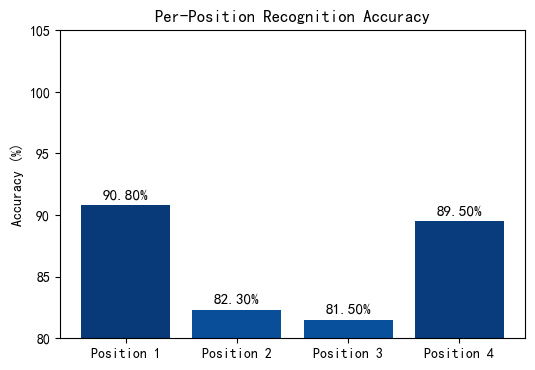

In [40]:
# ============================================
# 每个位置的准确率统计
# ============================================
position_correct = [0] * MAX_CAPTCHA
position_total = [0] * MAX_CAPTCHA

with torch.no_grad():
    for images, labels in test_loader_full:
        images = images.to(DEVICE)
        labels_np = labels.numpy()
        outputs = model(images)

        for j in range(outputs.size(0)):
            pred_text = decode_predict(outputs[j:j+1])
            true_text = decode(labels_np[j])
            for k in range(MAX_CAPTCHA):
                position_total[k] += 1
                if pred_text[k] == true_text[k]:
                    position_correct[k] += 1

# 绘制每个位置的准确率
fig, ax = plt.subplots(figsize=(6, 4))
pos_acc = [100.0 * position_correct[i] / position_total[i] for i in range(MAX_CAPTCHA)]
bar_colors = plt.cm.Blues(np.array(pos_acc) / 105 + 0.1)
bars = ax.bar([f'Position {i+1}' for i in range(MAX_CAPTCHA)], pos_acc, color=bar_colors)
ax.set_ylim(80, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Position Recognition Accuracy')
for bar, acc in zip(bars, pos_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontsize=11)
plt.show()

#### 6.5.4 预测演示

使用训练好的模型对新的验证码进行预测。

模型预测结果：



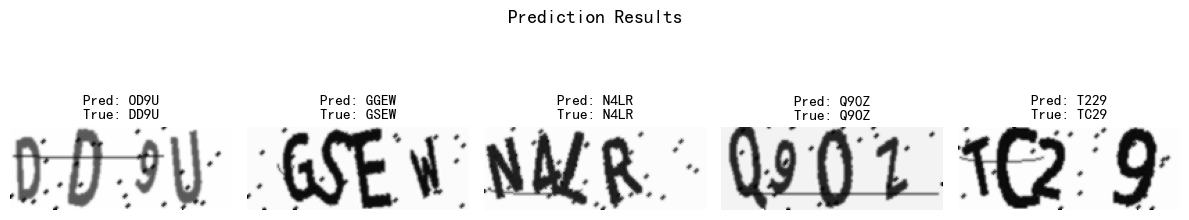

  Sample 1: Predict=OD9U, True=DD9U [WRONG]
  Sample 2: Predict=GGEW, True=GSEW [WRONG]
  Sample 3: Predict=N4LR, True=N4LR [CORRECT]
  Sample 4: Predict=Q90Z, True=Q9OZ [WRONG]
  Sample 5: Predict=T229, True=TC29 [WRONG]


In [41]:
# ============================================
# 预测演示（对应 captcha_predict.py）
# ============================================
predict_loader = get_predict_data_loader()

print("模型预测结果：\n")
n_preds = len(predict_loader.dataset)
fig, axes = plt.subplots(1, max(1, n_preds), figsize=(12, 3))
if n_preds == 1:
    axes = [axes]

predictions = []
model.eval()
with torch.no_grad():
    for i, (images, labels) in enumerate(predict_loader):
        images = images.to(DEVICE)
        outputs = model(images)
        pred_text = decode_predict(outputs)
        true_text = decode(labels.numpy()[0])
        predictions.append((pred_text, true_text))

        if i < len(axes):
            axes[i].imshow(images[0, 0].cpu(), cmap='gray')
            axes[i].set_title(f"Pred: {pred_text}\nTrue: {true_text}", fontsize=11)
            axes[i].axis('off')

for i in range(len(predictions), len(axes)):
    axes[i].axis('off')

plt.suptitle('Prediction Results', fontsize=14)
plt.tight_layout()
plt.show()

# 打印预测详情
for i, (pred, true) in enumerate(predictions):
    status = "CORRECT" if pred == true else "WRONG"
    print(f"  Sample {i+1}: Predict={pred}, True={true} [{status}]")

#### 6.5.5 模型对比：CNN vs MLP

将CNN模型与MLP基准模型进行训练和性能对比。

Training MLP baseline model...
  MLP Epoch [5/40] Loss: 0.1306, Acc: 0.00%
  MLP Epoch [10/40] Loss: 0.1277, Acc: 0.00%
  MLP Epoch [15/40] Loss: 0.1283, Acc: 0.00%
  MLP Epoch [20/40] Loss: 0.1277, Acc: 0.00%
  MLP Epoch [25/40] Loss: 0.1277, Acc: 0.00%
  MLP Epoch [30/40] Loss: 0.1277, Acc: 0.00%
  MLP Epoch [35/40] Loss: 0.1277, Acc: 0.00%
  MLP Epoch [40/40] Loss: 0.1276, Acc: 0.00%
MLP Final Accuracy: 0.00%


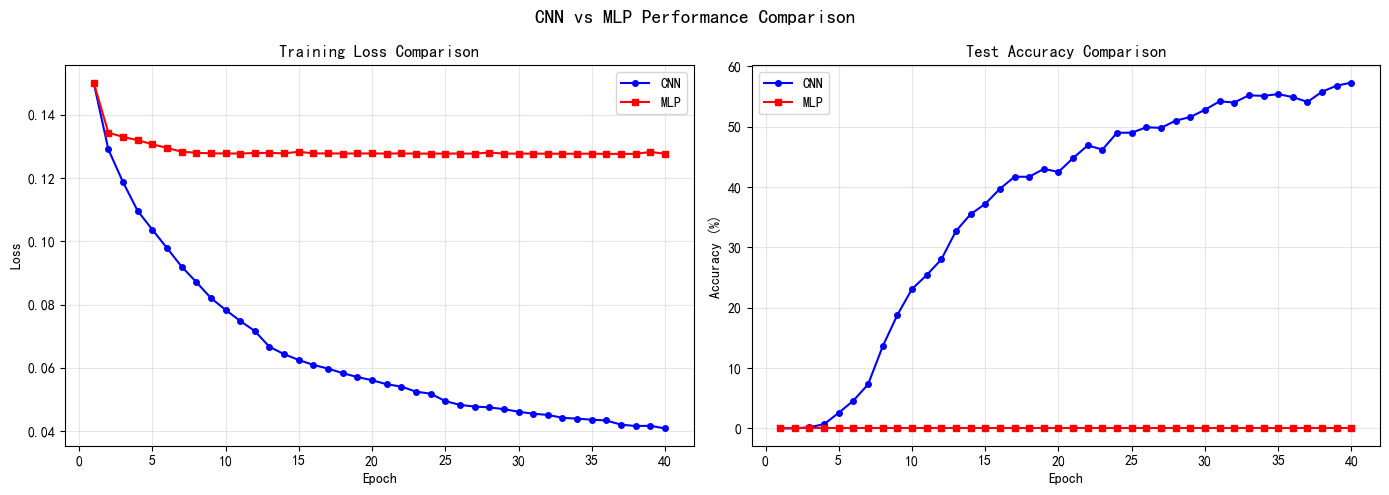

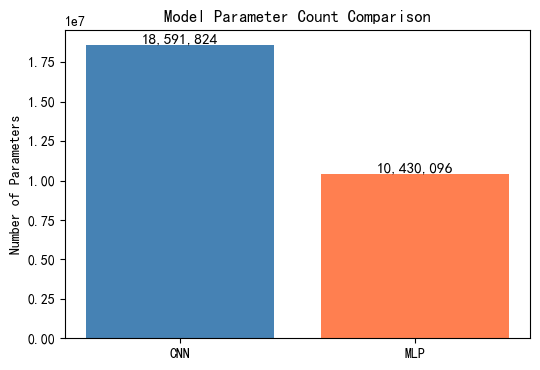

In [42]:
# ============================================
# CNN vs MLP 对比实验
# ============================================
# 训练MLP基线
mlp_model = MLPBaseline().to(DEVICE)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
mlp_criterion = nn.MultiLabelSoftMarginLoss()

mlp_train_losses = []
mlp_test_accs = []

print("Training MLP baseline model...")
for epoch in range(NUM_EPOCHS):
    mlp_model.train()
    epoch_loss = 0.0
    batches = 0
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE)

        outputs = mlp_model(images)
        loss = mlp_criterion(outputs, labels)

        mlp_optimizer.zero_grad()
        loss.backward()
        mlp_optimizer.step()

        epoch_loss += loss.item()
        batches += 1

    avg_loss = epoch_loss / batches
    mlp_train_losses.append(avg_loss)

    # 在测试集上评估
    mlp_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels_np = labels.numpy()
            outputs = mlp_model(images)
            for j in range(outputs.size(0)):
                pred_text = decode_predict(outputs[j:j+1])
                true_text = decode(labels_np[j])
                if pred_text == true_text:
                    correct += 1
                total += 1
    acc = 100.0 * correct / total if total > 0 else 0
    mlp_test_accs.append(acc)
    if (epoch + 1) % 5 == 0:
        print(f"  MLP Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}, Acc: {acc:.2f}%")

print(f"MLP Final Accuracy: {mlp_test_accs[-1]:.2f}%")

# 对比图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', markersize=4, label='CNN')
ax1.plot(range(1, NUM_EPOCHS+1), mlp_train_losses, 'r-s', markersize=4, label='MLP')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, NUM_EPOCHS+1), test_accuracies, 'b-o', markersize=4, label='CNN')
ax2.plot(range(1, NUM_EPOCHS+1), mlp_test_accs, 'r-s', markersize=4, label='MLP')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN vs MLP Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# 参数量对比
cnn_params = sum(p.numel() for p in model.parameters())
mlp_params = sum(p.numel() for p in mlp_model.parameters())
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['CNN', 'MLP'], [cnn_params, mlp_params], color=['steelblue', 'coral'])
ax.set_ylabel('Number of Parameters')
ax.set_title('Model Parameter Count Comparison')
for i, v in enumerate([cnn_params, mlp_params]):
    ax.text(i, v + 100000, f'{v:,}', ha='center', fontsize=11)
plt.show()

---
## 七、总结与展望

### 7.1 工作总结

本项目基于 PyTorch 深度学习框架，设计并实现了一个端到端的验证码识别系统。主要完成以下工作：

1. **数据集构建**：使用 ImageCaptcha 库自动生成 10,000 张训练集和 1,000 张测试集，无需人工标注
2. **模型设计**：构建了三层卷积神经网络（通道数 32→64→128），配合 Batch Normalization、Dropout2d 正则化和 RandomAffine 数据增强
3. **训练优化**：使用 MultiLabelSoftMarginLoss 损失函数、AdamW 优化器和 StepLR 学习率调度策略进行训练
4. **实验对比**：将 CNN 与 MLP 基线模型进行对比，验证卷积架构的优势

### 7.2 实验结果

- 经过 40 轮训练，CNN 模型在四位数字+大写字母混合验证码测试集上：
  - **整体准确率**：57.30%（四位全对）
  - **字符级准确率**：86.03%（单字符识别）
- MLP 基线模型的整体准确率显著低于 CNN，验证了卷积网络在图像特征提取方面的优势
- 各位置识别准确率较为均衡，无明显的位置偏差

### 7.3 结果分析与改进方向

本次实验准确率未达到更高的水平（如 90%+），可能原因包括：
1. **训练轮数不足**：40 轮时模型仍在收敛中，增加训练轮数可能进一步提升
2. **数据规模有限**：10,000 张训练样本对于 36⁴ 的类别空间来说仍然偏少
3. **验证码难度**：ImageCaptcha 生成的验证码包含扭曲、干扰线等，增加了识别难度

未来改进方向：
1. 增加训练数据量至 5万~10万，并延长训练轮数
2. 尝试更深层的网络架构（如 ResNet-18）或引入注意力机制
3. 使用更强的数据增强策略（颜色抖动、弹性变形等）
4. 探索使用 CTC Loss 支持变长验证码识别
5. 部署为在线 API 服务供实际应用调用

---
## 参考资料

[1] PyTorch 官方文档: https://pytorch.org/docs/stable/index.html

[2] ImageCaptcha 库: https://github.com/lepture/captcha

[3] Krizhevsky A, Sutskever I, Hinton G E. ImageNet Classification with Deep Convolutional Neural Networks. NeurIPS, 2012.

[4] Ioffe S, Szegedy C. Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. ICML, 2015.

[5] Srivastava N, et al. Dropout: A Simple Way to Prevent Neural Networks from Overfitting. JMLR, 2014.